In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from tqdm import tqdm

from collections import Counter
from collections import defaultdict

from albumentations.pytorch import ToTensorV2
import albumentations as A

import cv2
import numpy as np

import timm
from timm.data.mixup import Mixup

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import pandas as pd

import random
import os
from glob import glob


d:\LabsMIET\MLlab\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 9999
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [3]:
class_to_idx = { "Апельсин": 0,
                 "Бананы": 1,
                 "Груши": 2, 
                 "Кабачки": 3, 
                 "Капуста": 4, 
                 "Картофель": 5, 
                 "Киви": 6, 
                 "Лимон": 7, 
                 "Лук": 8, 
                 "Мандарины": 9, 
                 "Морковь": 10, 
                 "Огурцы": 11, 
                 "Томаты": 12, 
                 "Яблоки зелёные": 13, 
                 "Яблоки красные": 14 }

In [4]:
dataset_path = 'train/train'

writer = SummaryWriter("kirillLogs")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
class MyDataset(Dataset):
    def __init__(self, images_filepaths, name2label, transform=None):
        self.images_filepaths = images_filepaths
        self.transform = transform
        self.name2label = name2label

        self.labels = [
            name2label[os.path.normpath(p).split(os.sep)[-3]] 
            for p in images_filepaths
        ]
        
    def __len__(self):
        return len(self.images_filepaths)

    def __getitem__(self, idx):
        image_filepath = self.images_filepaths[idx]
        image = cv2.imdecode(np.fromfile(image_filepath, dtype=np.uint8), cv2.IMREAD_UNCHANGED)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.name2label[os.path.normpath(image_filepath).split(os.sep)[-3]]
        
        label = self.labels[idx]

        if self.transform is not None:
            image = self.transform(image=image)['image']
        return image, label

In [6]:
def collect_subclass_data(root_path):
    all_files = []
    # Это метка для StratifiedKFold (уникальная для каждого подкласса)
    subclass_labels_for_split = []

    # Счетчик для уникальных ID подклассов
    subclass_id_counter = 0

    # Проходим по Главным классам
    for class_name in os.listdir(root_path):
        class_path = os.path.join(root_path, class_name)
        if not os.path.isdir(class_path):
            continue

        # Проходим по Подклассам
        for subclass_name in os.listdir(class_path):
            subclass_path = os.path.join(class_path, subclass_name)
            if not os.path.isdir(subclass_path):
                continue

            images = glob(os.path.join(subclass_path, '*.jpg')) + \
                     glob(os.path.join(subclass_path, '*.png')) + \
                     glob(os.path.join(subclass_path, '*.jpeg'))

            if len(images) == 0:
                continue

            # Добавляем пути
            all_files.extend(images)

            subclass_labels_for_split.extend([subclass_id_counter] * len(images))

            subclass_id_counter += 1

    return np.array(all_files), np.array(subclass_labels_for_split)

In [7]:
all_files, all_labels = collect_subclass_data(dataset_path)

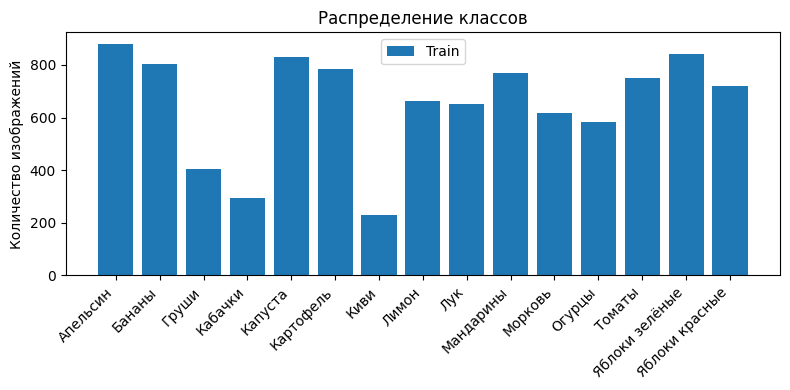

In [8]:
def count_classes(image_paths, class_to_idx):
    counts = Counter()
    for im_path in image_paths:
        class_name = os.path.normpath(im_path).split(os.sep)[-3]
        class_idx = class_to_idx[class_name]
        counts[class_idx] += 1
    return counts

data_counts = count_classes(all_files, class_to_idx)

idx2class = {v: k for k, v in class_to_idx.items()} # Конвертация class_to_idx -> idx2class

classes = list(idx2class.keys())
class_names = [idx2class[i] for i in classes]

data_values = [data_counts.get(i, 0) for i in classes]

x = np.arange(len(classes))

plt.figure(figsize=(8, 4))
plt.bar(x, data_values, label='Train')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylabel('Количество изображений')
plt.title('Распределение классов')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
IMG_SIZE = 224

train_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(
        min_height=IMG_SIZE,
        min_width=IMG_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=1.0
    ),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=5,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=0.5
    ),

    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.OneOf([
        A.GaussianBlur(blur_limit=(3), sigma_limit=(0.1, 1.0), p=0.5),
        A.GaussNoise(std_range=(0.01, 0.02), noise_scale_factor=0.7, p=0.9),
    ], p=0.9),

    A.CoarseDropout(
        num_holes_range=(1, 16),
        hole_height_range=(0.02, 0.1),
        hole_width_range=(0.02, 0.1),
        fill=0,
        p=0.75
    ),

    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    A.ToTensorV2(),
])

val_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(
        min_height=IMG_SIZE,
        min_width=IMG_SIZE,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=1.0
    ),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

C:\Users\Kirill\AppData\Local\Temp\ipykernel_9616\1317255609.py:5: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
d:\LabsMIET\MLlab\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\Kirill\AppData\Local\Temp\ipykernel_9616\1317255609.py:13: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
C:\Users\Kirill\AppData\Local\Temp\ipykernel_9616\1317255609.py:45: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(


In [10]:
@torch.no_grad()
def evaluate(model, dataloader, val_loss_fn, device, desc="Val"):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    all_preds = []
    all_labels = []

    pbar = tqdm(dataloader, desc=desc, leave=False)
    for X_batch, y_batch in pbar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(X_batch)
            loss = val_loss_fn(logits, y_batch)

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        y_pred = logits.argmax(dim=1)
        total_correct += (y_pred == y_batch).sum().item()
        total_samples += batch_size
        
        # Собираем данные для F1
        all_preds.extend(y_pred.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

        avg_loss = total_loss / max(total_samples, 1)
        acc = total_correct / max(total_samples, 1)
        pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{acc:.4f}")

    avg_loss = total_loss / max(total_samples, 1)
    accuracy = total_correct / max(total_samples, 1)
    
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    
    return accuracy, avg_loss, f1_weighted

In [11]:
def train(model, train_loss_fn, val_loss_fn, optimizer, train_loader, val_loader, 
          device, model_name, fold_idx=0, n_epoch=30, patience=6, lr_eta=1e-6,
          mixup_alpha=0.8, label_smoothing=0.1):
    
    scaler = torch.amp.GradScaler('cuda') 

    mixup_fn = Mixup(
        mixup_alpha=mixup_alpha,
        cutmix_alpha=1.0,
        prob=1.0,
        switch_prob=0.5,
        label_smoothing=label_smoothing,
        num_classes=15
    )

    best_f1 = 0.0
    best_epoch = 0
    counter = 0
    
    best_model_path = f"checkpoints/{model_name}_fold{fold_idx+1}_best.pth"
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epoch, eta_min=lr_eta)

    for epoch in range(1, n_epoch + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{n_epoch} [{model_name}]", leave=False)
        
        for X_batch, y_batch in pbar:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            X_batch, y_batch = mixup_fn(X_batch, y_batch)

            optimizer.zero_grad()
            
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16): 
                logits = model(X_batch)
                loss = train_loss_fn(logits, y_batch)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            
            y_pred = logits.argmax(dim=1)
            total_correct += (y_pred == y_batch.argmax(dim=1)).sum().item()
            total_samples += batch_size

            avg_loss = total_loss / max(total_samples, 1)
            acc = total_correct / max(total_samples, 1)
            pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{acc:.4f}")

        scheduler.step()

        val_acc, val_loss, val_f1 = evaluate(model, val_loader, val_loss_fn, device, 
                                             desc=f"Val Epoch {epoch}")

        print(f"Epoch {epoch:2d}/{n_epoch} | "
              f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
              f"val_f1_weighted={val_f1:.4f}")

        if val_f1 > best_f1 + 1e-5:
            best_f1 = val_f1
            best_epoch = epoch
            counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"    >>> Новая лучшая модель! F1 = {best_f1:.4f} (эпоха {epoch}) → сохранено")
        else:
            counter += 1
            print(f"    Нет улучшения F1 ({counter}/{patience})")

            if counter >= patience:
                print(f"\n>>> Early Stopping на эпохе {epoch}. Лучшая F1 weighted = {best_f1:.4f}")
                break

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"Фолд {fold_idx+1} завершён. Лучшая F1 = {best_f1:.4f} | Модель: {best_model_path}\n")

    return model

In [12]:
@torch.no_grad()
def sklearn_report(model, dataloader, device, idx2class=None, digits=4):
    model.eval()

    y_true, y_pred = [], []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()

        y_pred.append(preds)
        y_true.append(y_batch.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    if idx2class is None:
        target_names = None
        labels = None
    else:
        labels = sorted(idx2class.keys())
        target_names = [idx2class[i] for i in labels]

    rep = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        digits=digits,
        zero_division=0
    )
    print(rep)

    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    return f1_weighted

In [13]:
def class_weights(data_counts, num_classes, device):
    total_samples = sum(data_counts.values())
    weights = []

    for i in range(num_classes):
        count = data_counts[i]
        weight = total_samples / (num_classes * count)
        weights.append(weight)

    return torch.FloatTensor(weights).to(device)

class_weights = class_weights(data_counts, num_classes=15, device=device)
print("Веса классов:\n", class_weights)

Веса классов:
 tensor([0.7441, 0.8144, 1.6248, 2.2272, 0.7880, 0.8352, 2.8346, 0.9861, 1.0074,
        0.8493, 1.0613, 1.1232, 0.8742, 0.7795, 0.9082], device='cuda:0')


In [14]:
class SoftFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        # Если alpha передан как список или numpy array, конвертируем в тензор
        if alpha is not None and not isinstance(alpha, torch.Tensor):
            alpha = torch.tensor(alpha, dtype=torch.float32)
            
        self.register_buffer('alpha', alpha) 
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # logits: [batch, classes], targets: [batch, classes]
        
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        
        # Soft Cross Entropy
        ce_loss = -(targets * log_probs).sum(dim=-1)
        
        # Оценка уверенности модели (pt) взвешенная по таргетам
        pt = (targets * probs).sum(dim=-1)
        
        # Фокальный множитель
        modulating_factor = (1.0 - pt) ** self.gamma
        
        # Балансировка классов (Soft Alpha)
        if self.alpha is not None:
            alpha = self.alpha.to(targets.device)
            alpha_t = (targets * alpha).sum(dim=-1) 
            loss = alpha_t * modulating_factor * ce_loss
        else:
            loss = modulating_factor * ce_loss
            
        # Редукция
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        return loss

In [15]:
@torch.no_grad()
def create_predictions_table(model, dataloader, device, idx2class):
    model.eval()
    
    results = []
    
    for batch_idx, (images, true_labels) in enumerate(tqdm(dataloader, desc="Collecting predictions")):
        images = images.to(device)
        logits = model(images)
        probs = F.softmax(logits, dim=1)
        pred_labels = probs.argmax(dim=1).cpu().numpy()
        max_probs = probs.max(dim=1)[0].cpu().numpy()
        
        # Получаем пути к изображениям 
        if hasattr(dataloader.dataset, 'images_filepaths'):
            start_idx = batch_idx * dataloader.batch_size
            end_idx = start_idx + images.size(0)
            filepaths = dataloader.dataset.images_filepaths[start_idx:end_idx]
        else:
            filepaths = [f"batch_{batch_idx}_idx_{i}" for i in range(images.size(0))]
        
        for fp, true_lbl, pred_lbl, prob in zip(filepaths, true_labels.cpu().numpy(), pred_labels, max_probs):
            true_name = idx2class[true_lbl]
            pred_name = idx2class[pred_lbl]
            correct = true_lbl == pred_lbl
            
            results.append({
                'filepath': fp,
                'true_label': true_lbl,
                'true_class': true_name,
                'pred_label': pred_lbl,
                'pred_class': pred_name,
                'max_prob': round(float(prob), 4),
                'correct': correct
            })
    
    df = pd.DataFrame(results)
    
    # Сортируем по самым уверенным ошибкам
    errors = df[~df['correct']].sort_values('max_prob', ascending=False)
    print(f"Всего изображений: {len(df)}")
    print(f"Ошибок: {len(errors)} ({len(errors)/len(df):.2%})")
    
    return df, errors

In [16]:
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('confident_errors', exist_ok=True)
writer = SummaryWriter("logs")

n_fold = 5
epoch = 25
b_size = 32
lr_eta = 1e-6

skf = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=SEED)

val_loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.0)
train_loss_fn = SoftFocalLoss(alpha=class_weights, gamma=2.0)

model_hyperparams = {
    "regnety_040": {
        "lr": 2.5e-4,             
        "weight_decay": 0.015,     
        "patience": 5,
        "mixup_alpha": 0.4,       
        "label_smoothing": 0.10,
        "drop_path_rate": 0.05     
    },
    "maxvit_tiny_tf_224": {
        "lr": 1.5e-4,             
        "weight_decay": 0.05,     
        "patience": 5,
        "mixup_alpha": 0.4,
        "label_smoothing": 0.10,
        "drop_path_rate": 0.15     
    },
    "swin_tiny_patch4_window7_224": {
        "lr": 1.0e-4,
        "weight_decay": 0.02,
        "patience": 5,
        "mixup_alpha": 0.4,        
        "label_smoothing": 0.10,
        "drop_path_rate": 0.2     
    },
    "deit3_small_patch16_224": {
        "lr": 1.0e-4,
        "weight_decay": 0.025,
        "patience": 5,
        "mixup_alpha": 0.4,        
        "label_smoothing": 0.10,
        "drop_path_rate": 0.1    
    },
    "tf_efficientnetv2_s": {
        "lr": 2.5e-4,              
        "weight_decay": 0.02,     
        "patience": 5,
        "mixup_alpha": 0.4,
        "label_smoothing": 0.10,
        "drop_path_rate": 0.15  
    }
}

In [17]:
f1_scores_by_model = {name: [] for name in model_hyperparams.keys()}   

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(all_files, all_labels)):
    print(f"\n{'='*80}")
    print(f"Запуск фолда {fold_idx + 1}/{n_fold}")
    print(f"{'='*80}\n")

    train_files = all_files[train_idx]
    val_files   = all_files[val_idx]

    train_dataset = MyDataset(train_files, class_to_idx, transform=train_transforms)
    val_dataset   = MyDataset(val_files,   class_to_idx, transform=val_transforms)

    sample_weights = [class_weights[label].item() for label in train_dataset.labels]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(train_dataset),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=b_size,
        sampler=sampler,
        num_workers=0,
        pin_memory=True,
        persistent_workers=False,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=8,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    for model_name in model_hyperparams.keys():
        params = model_hyperparams[model_name]
        print(f"\n→ Обучаем модель: {model_name} | Фолд {fold_idx+1}/{n_fold}")

        # Создаём новую модель
        model = timm.create_model(
            model_name, 
            pretrained=True, 
            num_classes=15,
            drop_path_rate=params["drop_path_rate"]
        )
        model.to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])

        model = train(
            model=model,
            train_loss_fn=train_loss_fn,
            val_loss_fn=val_loss_fn,
            optimizer=optimizer,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            model_name=model_name,      
            fold_idx=fold_idx,
            n_epoch=epoch,
            patience=params["patience"],
            lr_eta=lr_eta,
            mixup_alpha=params["mixup_alpha"],
            label_smoothing=params["label_smoothing"]
        )

        # Оценка
        f1 = sklearn_report(
            model, 
            val_loader, 
            device, 
            idx2class={v: k for k, v in class_to_idx.items()}
        )
        
        f1_scores_by_model[model_name].append(f1)

        # Таблица ошибок
        val_df, val_errors = create_predictions_table(
            model, val_loader, device, 
            idx2class={v: k for k, v in class_to_idx.items()}
        )
        val_errors.to_csv(f"confident_errors/most_confident_errors_{model_name}_fold{fold_idx+1}.csv", index=False)

        # Очистка памяти
        del model, optimizer
        torch.cuda.empty_cache()

    # Очистка загрузчиков после всех моделей фолда
    del train_loader, val_loader
    torch.cuda.empty_cache()

Epoch 10/25 | val_loss=0.2227 | val_acc=0.9430 | val_f1_weighted=0.9443
    >>> Новая лучшая модель! F1 = 0.9443 (эпоха 10) → сохранено


Epoch 11/25 | val_loss=0.2170 | val_acc=0.9501 | val_f1_weighted=0.9501
    >>> Новая лучшая модель! F1 = 0.9501 (эпоха 11) → сохранено


Epoch 12/25 | val_loss=0.2052 | val_acc=0.9501 | val_f1_weighted=0.9501
    Нет улучшения F1 (1/5)


Epoch 13/25 | val_loss=0.1882 | val_acc=0.9532 | val_f1_weighted=0.9531
    >>> Новая лучшая модель! F1 = 0.9531 (эпоха 13) → сохранено


Epoch 14/25 | val_loss=0.2347 | val_acc=0.9455 | val_f1_weighted=0.9457
    Нет улучшения F1 (1/5)


...

Epoch 22/25 | val_loss=0.1601 | val_acc=0.9654 | val_f1_weighted=0.9654
    >>> Новая лучшая модель! F1 = 0.9654 (эпоха 22) → сохранено


Epoch 23/25 | val_loss=0.1617 | val_acc=0.9618 | val_f1_weighted=0.9618
    Нет улучшения F1 (1/5)


Epoch 24/25 | val_loss=0.1576 | val_acc=0.9649 | val_f1_weighted=0.9649
    Нет улучшения F1 (2/5)


Epoch 25/25 | val_loss=0.1603 | val_acc=0.9649 | val_f1_weighted=0.9649
    Нет улучшения F1 (3/5)
Фолд 5 завершён. Лучшая F1 = 0.9654 | Модель: checkpoints/tf_efficientnetv2_s_fold5_best.pth

                precision    recall  f1-score   support

      Апельсин     0.9613    0.9886    0.9748       176
        Бананы     0.9875    0.9875    0.9875       160
         Груши     0.9872    0.9506    0.9686        81
       Кабачки     0.9672    1.0000    0.9833        59
       Капуста     1.0000    0.9880    0.9939       166
     Картофель     0.9494    0.9554    0.9524       157
          Киви     0.8542    0.8913    0.8723        46
         Лимон     0.9848    0.9774    0.9811       133
           Лук     0.8978    0.9462    0.9213       130
     Мандарины     0.9608    0.9545    0.9577       154
       Морковь     0.9829    0.9350    0.9583       123
        Огурцы     0.9669    1.0000    0.9832       117
        Томаты     0.9864    0.9667    0.9764       150
Яблоки зелёные     0.9

Всего изображений: 1964
Ошибок: 69 (3.51%)


In [18]:
submission_path = "sample_submission.csv"
output_path = "submissionFinal.csv"
test_images_dir = "test_images/test_images"

In [22]:
POWER = 4.0 

submission = pd.read_csv(submission_path)
final_predictions = []

print("Загрузка моделей для ансамбля...")

models = []           
model_weights = []    

for model_name in model_hyperparams.keys():                    
    f1_list = f1_scores_by_model[model_name]      
    
    for fold in range(n_fold):
        fold_score = f1_list[fold]
        
        path = f"checkpoints/{model_name}_fold{fold+1}_best.pth"
        
        # Создаем и загружаем
        model_i = timm.create_model(model_name, pretrained=False, num_classes=15)
        model_i.load_state_dict(torch.load(path, map_location=device))
        model_i.to(device)
        model_i.eval()
        
        models.append(model_i)
        model_weights.append(fold_score)   
        
        print(f"Загружена: {model_name} | Fold {fold+1} | F1={fold_score:.4f}")

model_weights = np.array(model_weights)

model_weights = model_weights ** POWER

model_weights = model_weights / model_weights.sum()

print(f"\nВсего моделей: {len(models)}")
print(f"Применен Power Weighting (p={POWER}).")
print(f"Мин. вес: {model_weights.min():.4f} | Макс. вес: {model_weights.max():.4f}")
print("Готов к предсказанию...\n")

Загрузка моделей для ансамбля...
Загружена: regnety_040 | Fold 1 | F1=0.9684
Загружена: regnety_040 | Fold 2 | F1=0.9679
Загружена: regnety_040 | Fold 3 | F1=0.9668
Загружена: regnety_040 | Fold 4 | F1=0.9666
Загружена: regnety_040 | Fold 5 | F1=0.9593
Загружена: maxvit_tiny_tf_224 | Fold 1 | F1=0.9705
Загружена: maxvit_tiny_tf_224 | Fold 2 | F1=0.9745
Загружена: maxvit_tiny_tf_224 | Fold 3 | F1=0.9761
Загружена: maxvit_tiny_tf_224 | Fold 4 | F1=0.9746
Загружена: maxvit_tiny_tf_224 | Fold 5 | F1=0.9705
Загружена: swin_tiny_patch4_window7_224 | Fold 1 | F1=0.9694
Загружена: swin_tiny_patch4_window7_224 | Fold 2 | F1=0.9755
Загружена: swin_tiny_patch4_window7_224 | Fold 3 | F1=0.9730
Загружена: swin_tiny_patch4_window7_224 | Fold 4 | F1=0.9445
Загружена: swin_tiny_patch4_window7_224 | Fold 5 | F1=0.9665
Загружена: deit3_small_patch16_224 | Fold 1 | F1=0.9678
Загружена: deit3_small_patch16_224 | Fold 2 | F1=0.9740
Загружена: deit3_small_patch16_224 | Fold 3 | F1=0.9700
Загружена: deit3_sm

In [23]:
with torch.no_grad():
    for image_id in tqdm(submission["image_id"], desc="Predicting"):
        
        image_path = os.path.join(test_images_dir, image_id)
        image = cv2.imdecode(np.fromfile(image_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if val_transforms is not None:
            image = val_transforms(image=image)["image"]
        
        img = image.to(device).unsqueeze(0)  
        
        img_orig = img
        img_h    = torch.flip(img, [3])      
        img_v    = torch.flip(img, [2])      
        img_hv   = torch.flip(img, [2, 3])  
        
        batch_tta = torch.cat([img_orig, img_h, img_v, img_hv], dim=0) 

        # Собираем вероятности
        all_probs = []
        
        for m in models:
            logits = m(batch_tta)                    
            probs = F.softmax(logits, dim=1)         
            avg_prob = probs.mean(dim=0)            
            all_probs.append(avg_prob)
        
        stacked_probs = torch.stack(all_probs)       
        
        weights_tensor = torch.tensor(model_weights, device=device, dtype=torch.float32).view(-1, 1)
        weighted_probs = (stacked_probs * weights_tensor).sum(dim=0)
        
        # Финальное предсказание
        pred_idx = weighted_probs.argmax().item()
        final_predictions.append(pred_idx)

# Сохранение
submission["label"] = final_predictions
submission.to_csv(output_path, index=False)
print(f"Файл сохранен: {output_path}")
submission.head()

Predicting: 100%|██████████| 2503/2503 [23:47<00:00,  1.75it/s]

Файл сохранен: submissionFinal.csv


,image_id,label
0,fd343552326b42c5a62c192f32549dc7.jpg,2
1,445ca69812cf44f581cc8a89223af277.jpg,7
2,570626ce4d8f41edb8088f49d40a2195.jpg,7
3,02d4acba92f343d798adcb4958fe684b.jpg,11
4,2d4b8e8f38534a39b0d02c440e917b83.jpg,12
